<a href="https://colab.research.google.com/github/Mahavishnu30/Diabetes-Prediction/blob/main/Feature_Selection_Diabetes_Prediction_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

In [9]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

print("Basic data check...")
print(f"Original data: {df.shape}")

Saving diabetes_cleaned (1).csv to diabetes_cleaned (1) (2).csv
Basic data check...
Original data: (55046, 15)


In [10]:
df = df.drop_duplicates()
df['diabetes'] = df['diabetes'].astype(int)

print(f"Cleaned data: {df.shape}")
print("Data loaded and cleaned!")

Cleaned data: (53795, 15)
Data loaded and cleaned!


In [11]:
def create_features(df):
    """Create new features"""
    df_new = df.copy()

    # BMI categories
    df_new['bmi_category'] = pd.cut(df_new['bmi'],
                                  bins=[0, 18.5, 25, 30, 100],
                                  labels=['Under', 'Normal', 'Over', 'Obese'])

    # Age groups
    df_new['age_group'] = pd.cut(df_new['age'],
                               bins=[0, 30, 45, 60, 100],
                               labels=['Young', 'Middle', 'Senior', 'Elderly'])

    # Simple risk score
    df_new['risk_score'] = (df_new['HbA1c_level'] * 0.4 +
                          df_new['blood_glucose_level'] * 0.3 +
                          df_new['bmi'] * 0.2 +
                          df_new['age'] * 0.1)

    # Convert categories to numbers
    df_new = pd.get_dummies(df_new, columns=['gender', 'smoking_history', 'bmi_category', 'age_group'])

    print(f"Created new features! New shape: {df_new.shape}")
    return df_new

# Apply feature engineering
df = create_features(df)


Created new features! New shape: (53795, 31)


Finding important features...

 Top 10 important features:
1. HbA1c_level
2. risk_score
3. blood_glucose_level
4. bmi
5. age
6. hypertension
7. age_group_Elderly
8. heart_disease
9. bmi_category_Obese
10. smoking_history_never

 Feature Importance Scores:
                  feature  importance
4             HbA1c_level    0.336007
12             risk_score    0.267012
5     blood_glucose_level    0.159971
3                     bmi    0.080284
0                     age    0.069526
1            hypertension    0.013007
29      age_group_Elderly    0.011315
2           heart_disease    0.009087
25     bmi_category_Obese    0.006590
20  smoking_history_never    0.005813


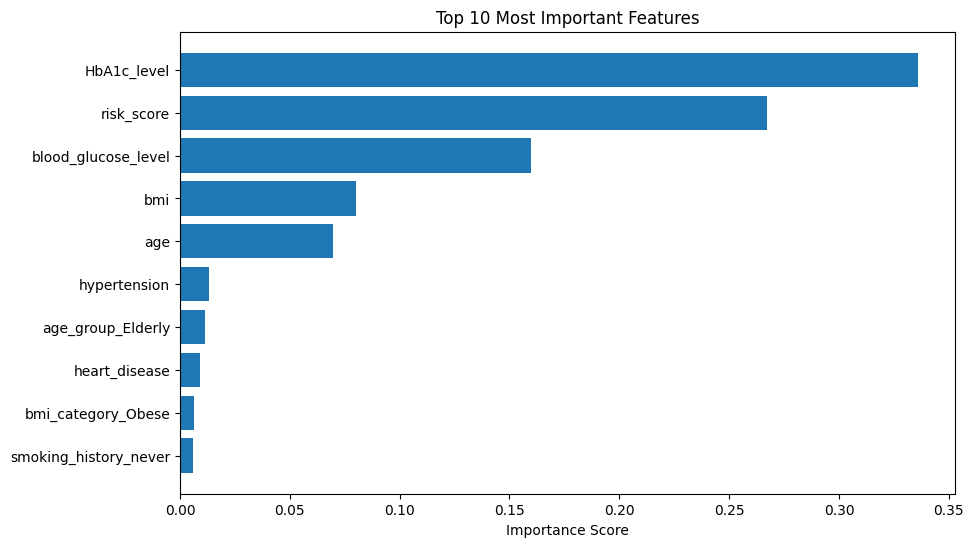


 Importance Statistics:
Most important feature: HbA1c_level (score: 0.336)
Average importance: 0.033
Number of features with importance > 0.01: 7

 Selected 10 features for modeling
Final feature set shape: (53795, 10)


In [12]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Finding important features...")

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Get feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = importance.head(10)['feature'].tolist()

print("\n Top 10 important features:")
for i, feature in enumerate(top_features, 1):
    print(f"{i}. {feature}")

# Show importance scores
print("\n Feature Importance Scores:")
print(importance.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_10_importance = importance.head(10)
plt.barh(top_10_importance['feature'], top_10_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Most important at top
plt.show()

# Show importance statistics
print(f"\n Importance Statistics:")
print(f"Most important feature: {importance.iloc[0]['feature']} (score: {importance.iloc[0]['importance']:.3f})")
print(f"Average importance: {importance['importance'].mean():.3f}")
print(f"Number of features with importance > 0.01: {(importance['importance'] > 0.01).sum()}")

# Use only important features
X_selected = X[top_features]

print(f"\n Selected {len(top_features)} features for modeling")
print(f"Final feature set shape: {X_selected.shape}")